In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from morl_behavior_objective.analysis.metrics_clean import compute_zadu_metrics
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants
from morl_behavior_objective.utils import load_ground_truth_data
from morl_behavior_objective.utils import load_transformer_embeddings

# Set matplotlib parameters
mpl.rcParams["pdf.fonttype"] = 42  # use true-type
mpl.rcParams["ps.fonttype"] = 42  # use true-type
mpl.rcParams["font.size"] = 18
mpl.rcParams["lines.linewidth"] = 2.2
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath,amssymb,underscore}"
mpl.rcParams["text.usetex"] = True
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 16

colors = [
    "#5CB5FF",
    "#D55E00",
    "#009E73",
    "#e6194b",
]

/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-concave-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/ffelte/Doc

## Load all the data

### Ground Truth and Returns embeddings

In [2]:
seed = 4
# Configuration for datasets
datasets = {
    "left_right": {
        "name": "left_right_dst",
        "num_files": 6,
        "embedding_path": f"../../trajectories/left_right_dst/embeddings/mean_be_DSTLR_e100_seed{seed}.json"
    },
    "smooth": {
        "name": "smooth",
        "num_files": 10,
        "embedding_path": f"../../trajectories/smooth/embeddings/mean_be_DSTS_e100_seed{seed}.json"
    }
}

# Load ground truth data
all_gt_emb, all_returns_lr = load_ground_truth_data(
    datasets["left_right"]["name"],
    datasets["left_right"]["num_files"]
)

all_gt_emb_smooth, all_returns_smooth = load_ground_truth_data(
    datasets["smooth"]["name"],
    datasets["smooth"]["num_files"]
)

# Load transformer embeddings
all_t_emb_lr, _ = load_transformer_embeddings(datasets["left_right"]["embedding_path"])  # noqa: N816
all_t_emb_smooth, _ = load_transformer_embeddings(datasets["smooth"]["embedding_path"])

# Print summary
print("Ground truth data loaded successfully:")
print(f" Ground truth embeddings Left right:  all_gt_emb shape: {all_gt_emb.shape}")
print(f" Ground truth returns Left right:  all_returns_lr shape: {all_returns_lr.shape}")
print(f" Ground truth embeddings Smooth:  all_gt_emb_smooth shape: {all_gt_emb_smooth.shape}")
print(f" Ground truth returns Smooth:  all_returns_smooth shape: {all_returns_smooth.shape}")
print("\nTransformer embeddings loaded successfully:")
print(f" Transformer embeddings Left right 3D:  all_t_emb_3D shape: {all_t_emb_lr.shape}")
print(f" Transformer embeddings Smooth new:  all_t_emb_smooth_new shape: {all_t_emb_smooth.shape}")


Ground truth data loaded successfully:
 Ground truth embeddings Left right:  all_gt_emb shape: (6, 2)
 Ground truth returns Left right:  all_returns_lr shape: (6, 2)
 Ground truth embeddings Smooth:  all_gt_emb_smooth shape: (10, 2)
 Ground truth returns Smooth:  all_returns_smooth shape: (10, 2)

Transformer embeddings loaded successfully:
 Transformer embeddings Left right 3D:  all_t_emb_3D shape: (6, 3)
 Transformer embeddings Smooth new:  all_t_emb_smooth_new shape: (10, 3)


## Trustworthiness and Continuity

In [3]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns

lipschitz_constants_lr_gt, d_objs_lr_gt, d_embs_lr_gt, sorted_pf_lr_gt, sorted_emb_lr_gt = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_gt_emb)
lipschitz_constants_lr_t, d_objs_lr_t, d_embs_lr_t, sorted_pf_lr_t, sorted_emb_lr_t = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_t_emb_lr)

lipschitz_constants_smooth_gt, d_objs_smooth_gt, d_embs_smooth_gt, sorted_pf_smooth_gt, sorted_emb_smooth_gt = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_gt_emb_smooth)
lipschitz_constants_smooth_t, d_objs_smooth_t, d_embs_smooth_t, sorted_pf_smooth_t, sorted_emb_smooth_t = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_t_emb_smooth)

print("Left-Right front", all_returns_lr)
print(f"Lipschitz constants Left-Right: {lipschitz_constants_lr_gt}")
print(f"Lipschitz constants Ground Truth Smooth: {lipschitz_constants_smooth_gt}")
print(f"Lipschitz constants Transformer Left-Right: {lipschitz_constants_lr_t}")
print(f"Lipschitz constants Transformer Smooth: {lipschitz_constants_smooth_t}")

Computing Lipschitz constant between policy 0 and 1
4.123105625617661
18.027756377319946
Lipshitz: 4.372373160976031
Lipschitz constant for policy 0 ([124. -19.], [ 9 10]) to 1 ([120. -18.], [-9  9]): 4.372373160976031, d_obj: 4.123105625617661, d_emb: 18.027756377319946
Computing Lipschitz constant between policy 1 and 2
95.08417323613851
2.8284271247461903
Lipshitz: 0.02974656063656232
Lipschitz constant for policy 1 ([120. -18.], [-9  9]) to 2 ([ 25. -14.], [-7  7]): 0.02974656063656232, d_obj: 95.08417323613851, d_emb: 2.8284271247461903
Computing Lipschitz constant between policy 2 and 3
1.4142135623730951
13.0
Lipshitz: 9.192388155425117
Lipschitz constant for policy 2 ([ 25. -14.], [-7  7]) to 3 ([ 24. -13.], [6 7]): 9.192388155425117, d_obj: 1.4142135623730951, d_emb: 13.0
Computing Lipschitz constant between policy 3 and 4
17.72004514666935
10.44030650891055
Lipshitz: 0.5891805817928689
Lipschitz constant for policy 3 ([ 24. -13.], [6 7]) to 4 ([ 7. -8.], [-4  4]): 0.589180581

In [4]:
from zadu.zadu import trustworthiness_continuity

# This computes average and std trustworthiness and continuity over all seeds
print("=== ZADU METRICS COMPUTATION ===")

trustworthiness_lr_pf_gt = []
trustworthiness_lr_pf_t = []
trustworthiness_lr_t_gt = []

trustworthiness_smooth_pf_gt = []
trustworthiness_smooth_pf_t = []
trustworthiness_smooth_t_gt = []

continuity_lr_pf_gt = []
continuity_lr_pf_t = []
continuity_lr_t_gt = []

continuity_smooth_pf_gt = []
continuity_smooth_pf_t = []
continuity_smooth_t_gt = []

for seed in range(5):
    # Configuration for datasets
    datasets = {
    "left_right": {
        "name": "left_right_dst",
        "num_files": 6,
        "embedding_path": f"../../trajectories/left_right_dst/embeddings/mean_be_DSTLR_e100_seed{seed}.json"
    },
    "smooth": {
        "name": "smooth",
        "num_files": 10,
        "embedding_path": f"../../trajectories/smooth/embeddings/mean_be_DSTS_e100_seed{seed}.json"
    }
    }

    # Load ground truth data
    all_gt_emb_seed, all_returns_lr_seed = load_ground_truth_data(
        datasets["left_right"]["name"],
        datasets["left_right"]["num_files"]
    )

    all_gt_emb_smooth_seed, all_returns_smooth_seed = load_ground_truth_data(
        datasets["smooth"]["name"],
        datasets["smooth"]["num_files"]
    )


    all_t_emb_lr_seed, _ = load_transformer_embeddings(datasets["left_right"]["embedding_path"])
    all_t_emb_smooth_seed, _ = load_transformer_embeddings(datasets["smooth"]["embedding_path"])

    lr_pf_gt = compute_zadu_metrics(all_returns_lr_seed, all_gt_emb_seed)
    lr_pf_t = compute_zadu_metrics(all_returns_lr_seed, all_t_emb_lr_seed)
    lr_t_gt = compute_zadu_metrics(all_gt_emb_seed, all_t_emb_lr_seed)

    trustworthiness_lr_pf_gt.append(lr_pf_gt[0]["trustworthiness"])
    trustworthiness_lr_pf_t.append(lr_pf_t[0]["trustworthiness"])
    trustworthiness_lr_t_gt.append(lr_t_gt[0]["trustworthiness"])
    continuity_lr_pf_gt.append(lr_pf_gt[0]["continuity"])
    continuity_lr_pf_t.append(lr_pf_t[0]["continuity"])
    continuity_lr_t_gt.append(lr_t_gt[0]["continuity"])

    smooth_pf_gt = compute_zadu_metrics(all_returns_smooth, all_gt_emb_smooth_seed)
    smooth_pf_t = compute_zadu_metrics(all_returns_smooth_seed, all_t_emb_smooth_seed)
    smooth_t_gt = compute_zadu_metrics(all_gt_emb_smooth_seed, all_t_emb_smooth_seed)
    
    trustworthiness_smooth_pf_gt.append(smooth_pf_gt[0]["trustworthiness"])
    trustworthiness_smooth_pf_t.append(smooth_pf_t[0]["trustworthiness"])
    trustworthiness_smooth_t_gt.append(smooth_t_gt[0]["trustworthiness"])
    continuity_smooth_pf_gt.append(smooth_pf_gt[0]["continuity"])
    continuity_smooth_pf_t.append(smooth_pf_t[0]["continuity"])
    continuity_smooth_t_gt.append(smooth_t_gt[0]["continuity"])


print("trustworthiness_lr_pf_gt", trustworthiness_lr_pf_gt)
print("trustworthiness_lr_pf_t", trustworthiness_lr_pf_t)
print("trustworthiness_lr_t_gt", trustworthiness_lr_t_gt)
print("trustworthiness_smooth_pf_gt", trustworthiness_smooth_pf_gt)
print("trustworthiness_smooth_pf_t", trustworthiness_smooth_pf_t)
print("trustworthiness_smooth_t_gt", trustworthiness_smooth_t_gt)





=== ZADU METRICS COMPUTATION ===
trustworthiness_lr_pf_gt [0.5666666666666665, 0.5666666666666665, 0.5666666666666665, 0.5666666666666665, 0.5666666666666665]
trustworthiness_lr_pf_t [0.5666666666666665, 0.5666666666666665, 0.8666666666666667, 0.5666666666666665, 0.3999999999999999]
trustworthiness_lr_t_gt [1.0, 1.0, 0.5333333333333333, 1.0, 0.8333333333333334]
trustworthiness_smooth_pf_gt [1.0, 1.0, 1.0, 1.0, 1.0]
trustworthiness_smooth_pf_t [0.8923076923076924, 0.8923076923076924, 0.8923076923076924, 0.8923076923076924, 0.8923076923076924]
trustworthiness_smooth_t_gt [0.8923076923076924, 0.8923076923076924, 0.8923076923076924, 0.8923076923076924, 0.8923076923076924]


In [5]:

print("=== ZADU METRICS COMPUTATION ===")

# 1. Raw metrics
print("\n--- Left right ---")

print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns_lr, all_gt_emb))
print("Left-right: Returns vs TE 3D:", compute_zadu_metrics(all_returns_lr, all_t_emb_lr))
print("Left-right: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb, all_t_emb_lr))


print("\n--- Smooth ---")
print("Smooth: Returns vs TE:", compute_zadu_metrics(all_returns_smooth, all_t_emb_smooth))
print("Smooth: Returns vs GTE:", compute_zadu_metrics(all_returns_smooth, all_gt_emb_smooth))
print("Smooth: GTE vs TE:", compute_zadu_metrics(all_gt_emb_smooth, all_t_emb_smooth))

=== ZADU METRICS COMPUTATION ===

--- Left right ---
Left-right: Returns vs GTE: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.5}, {'mrre_false': 0.5897435897435898, 'mrre_missing': 0.5}]
Left-right: Returns vs TE 3D: [{'trustworthiness': 0.3999999999999999, 'continuity': 0.2333333333333333}, {'mrre_false': 0.5, 'mrre_missing': 0.35897435897435903}]
Left-right: GTE vs TE 3D: [{'trustworthiness': 0.8333333333333334, 'continuity': 0.7999999999999999}, {'mrre_false': 0.8205128205128206, 'mrre_missing': 0.858974358974359}]

--- Smooth ---
Smooth: Returns vs TE: [{'trustworthiness': 0.8923076923076924, 'continuity': 0.976923076923077}, {'mrre_false': 0.844, 'mrre_missing': 0.9199999999999999}]
Smooth: Returns vs GTE: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 1.0, 'mrre_missing': 1.0}]
Smooth: GTE vs TE: [{'trustworthiness': 0.8923076923076924, 'continuity': 0.976923076923077}, {'mrre_false': 0.844, 'mrre_missing': 0.9199999999999999}]


## Scatter plots

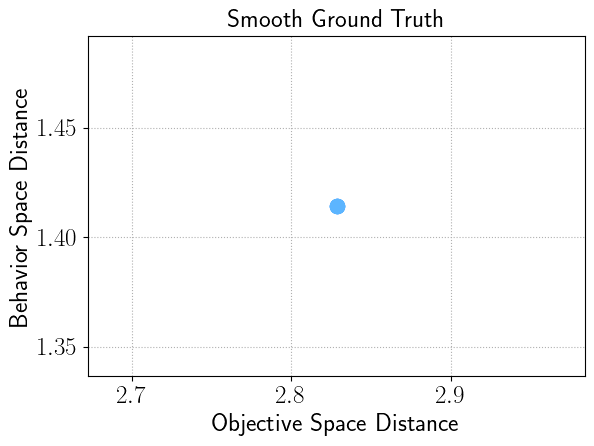

In [6]:
plt.scatter(d_objs_smooth_gt, d_embs_smooth_gt, c=colors[0], marker="o", s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Behavior Space Distance")
plt.title("Smooth Ground Truth")


plt.grid(True, linestyle=":")
plt.tight_layout()

plt.savefig("scatterplots/smooth_ground_truth.pdf")
plt.show()

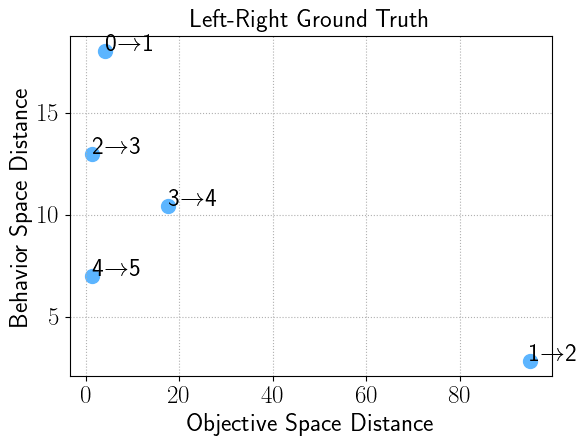

In [7]:
# Plot ground truth scatter plots
plt.scatter(d_objs_lr_gt, d_embs_lr_gt, c=colors[0], marker="o", s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Behavior Space Distance")
plt.title("Left-Right Ground Truth")
# add index as text labels
for i, txt in enumerate(range(len(d_objs_lr_gt))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i+1}", (d_objs_lr_gt[i], d_embs_lr_gt[i]))


plt.grid(True, linestyle=":")
plt.tight_layout()

plt.savefig("scatterplots/left_right_ground_truth.pdf")
plt.show()


In [8]:
def plot_scatter_distances(d_objs_lr_t, d_embs_lr_t, instance):

    print("Distance between points in objective space and embedding space")
    for i in range(len(d_objs_lr_t)):
        print(f"Distance {i} and {i+1} in objective space: {d_objs_lr_t[i]}")
        print(f"Distance {i} and {i+1} in embedding space: {d_embs_lr_t[i]}")

    plt.scatter(d_objs_lr_t, d_embs_lr_t, c=colors[0], marker="o", s=100)
    plt.xlabel("Objective Space Distance")
    plt.ylabel("Behavior Space Distance")
    plt.title(f"{instance} Transformer")
    # add index as text labels
    for i, txt in enumerate(range(len(d_objs_lr_t))):
        plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i+1}", (d_objs_lr_t[i], d_embs_lr_t[i]))

    plt.grid(True, linestyle=":")
    plt.tight_layout()


plot_scatter_distances(d_objs_lr_t, d_embs_lr_t, "Left-Right")
plt.savefig(f"scatterplots/left_right_transformer_{seed}.pdf")
plt.close()
plot_scatter_distances(d_objs_smooth_t, d_embs_smooth_t, "Smooth")
plt.savefig(f"scatterplots/smooth_transformer_{seed}.pdf")
plt.close()




Distance between points in objective space and embedding space
Distance 0 and 1 in objective space: 4.123105625617661
Distance 0 and 1 in embedding space: 1.9413261737092034
Distance 1 and 2 in objective space: 95.08417323613851
Distance 1 and 2 in embedding space: 0.6956616975694093
Distance 2 and 3 in objective space: 1.4142135623730951
Distance 2 and 3 in embedding space: 1.8921752716009042
Distance 3 and 4 in objective space: 17.72004514666935
Distance 3 and 4 in embedding space: 1.9991598357338145
Distance 4 and 5 in objective space: 1.4142135623730951
Distance 4 and 5 in embedding space: 1.825168995538228
Distance between points in objective space and embedding space
Distance 0 and 1 in objective space: 2.8284271247461903
Distance 0 and 1 in embedding space: 0.5633900920401127
Distance 1 and 2 in objective space: 2.8284271247461903
Distance 1 and 2 in embedding space: 0.6155438371963943
Distance 2 and 3 in objective space: 2.8284271247461903
Distance 2 and 3 in embedding space: 0

## Visualize embeddings

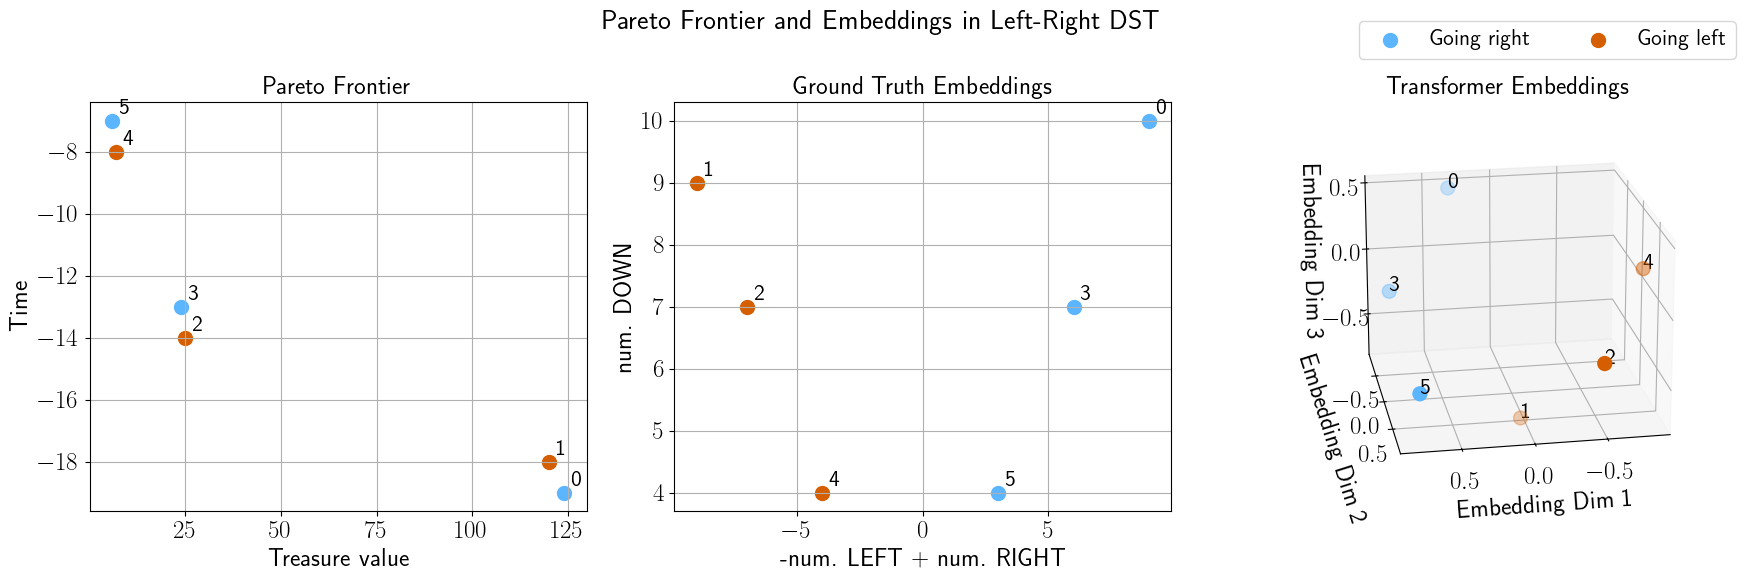

In [9]:
fig = plt.figure(figsize=(18, 6))

fig.suptitle("Pareto Frontier and Embeddings in Left-Right DST", fontsize=20)

# Define point groups
left_indices = [1, 2, 4]  # Going left (orange)
right_indices = [i for i in range(len(sorted_pf_lr_gt)) if i not in left_indices]  # Going right (blue)

# 2D scatter for returns (use sorted version)
ax2 = fig.add_subplot(131)
ax2.scatter(sorted_pf_lr_gt[right_indices,0], sorted_pf_lr_gt[right_indices,1], 
            c=colors[0], marker="o", label="Going right", s=100)
ax2.scatter(sorted_pf_lr_gt[left_indices,0], sorted_pf_lr_gt[left_indices,1], 
            c=colors[1], marker="o", label="Going left", s=100)
ax2.set_title("Pareto Frontier")
ax2.set_xlabel("Treasure value")
ax2.grid(True)
ax2.set_ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_lr_gt)):
    ax2.annotate(str(i), (sorted_pf_lr_gt[i,0], sorted_pf_lr_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 2D scatter for ground truth embeddings (use sorted version)
ax3 = fig.add_subplot(132)
ax3.scatter(sorted_emb_lr_gt[right_indices,0], sorted_emb_lr_gt[right_indices,1], 
            c=colors[0], marker="o", label="Going right", s=100)
ax3.scatter(sorted_emb_lr_gt[left_indices,0], sorted_emb_lr_gt[left_indices,1], 
            c=colors[1], marker="o", label="Going left", s=100)
ax3.set_title("Ground Truth Embeddings")
ax3.set_xlabel("-num. LEFT + num. RIGHT")
ax3.set_ylabel("num. DOWN")
ax3.grid(True)
# Add numbered labels
for i in range(len(sorted_emb_lr_gt)):
    ax3.annotate(str(i), (sorted_emb_lr_gt[i,0], sorted_emb_lr_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 3D scatter for transformer embeddings (use sorted version)
ax1 = fig.add_subplot(133, projection="3d")
ax1.scatter(sorted_emb_lr_t[right_indices,0], sorted_emb_lr_t[right_indices,1], sorted_emb_lr_t[right_indices,2], 
            c=colors[0], marker="o", label="Going right", s=100)
ax1.scatter(sorted_emb_lr_t[left_indices,0], sorted_emb_lr_t[left_indices,1], sorted_emb_lr_t[left_indices,2], 
            c=colors[1], marker="o", label="Going left", s=100)
ax1.set_title("Transformer Embeddings")
ax1.set_xlabel("Embedding Dim 1", labelpad=10)
ax1.set_ylabel("Embedding Dim 2", labelpad=10)
ax1.set_zlabel("Embedding Dim 3", labelpad=10)
ax1.grid(True)
# change view
ax1.view_init(elev=20, azim=80)
# Add numbered labels
for i in range(len(sorted_emb_lr_t)):
    ax1.text(sorted_emb_lr_t[i,0], sorted_emb_lr_t[i,1], sorted_emb_lr_t[i,2], str(i), fontsize=16)

# Create a single legend for the entire figure
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), ncol=2)

plt.tight_layout()
plt.savefig("pareto_front_embeddings_left_right.pdf")
plt.show()

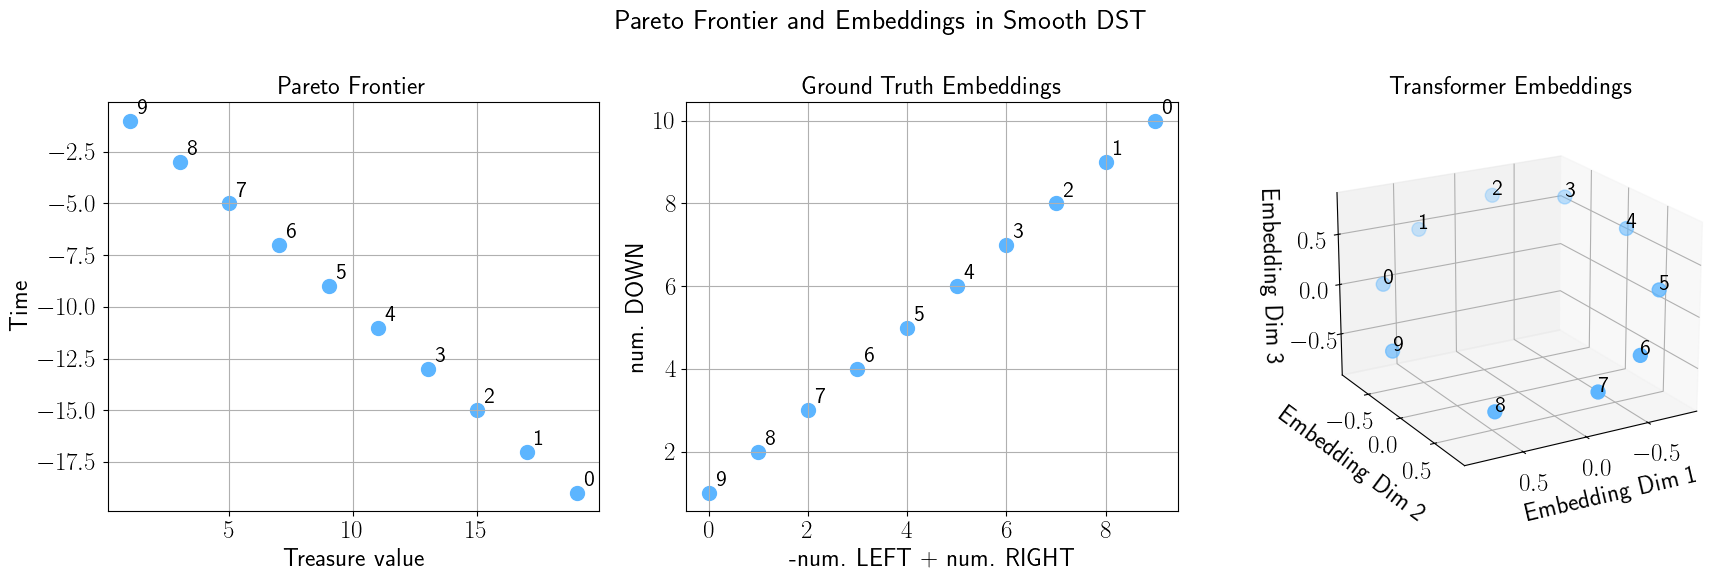

In [10]:
fig = plt.figure(figsize=(18, 6))

fig.suptitle("Pareto Frontier and Embeddings in Smooth DST", fontsize=20)

# 2D scatter for returns (use sorted version)
ax2 = fig.add_subplot(131)
ax2.scatter(sorted_pf_smooth_gt[:,0], sorted_pf_smooth_gt[:,1], c=colors[0], marker="o", s=100)
ax2.set_title("Pareto Frontier")
ax2.set_xlabel("Treasure value")
ax2.grid(True)
ax2.set_ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_smooth_gt)):
    ax2.annotate(str(i), (sorted_pf_smooth_gt[i,0], sorted_pf_smooth_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 2D scatter for ground truth embeddings (use sorted version)
ax3 = fig.add_subplot(132)
ax3.scatter(sorted_emb_smooth_gt[:,0], sorted_emb_smooth_gt[:,1], 
            c=colors[0], marker="o", s=100)
ax3.set_title("Ground Truth Embeddings")
ax3.set_xlabel("-num. LEFT + num. RIGHT")
ax3.set_ylabel("num. DOWN")
ax3.grid(True)
# Add numbered labels
for i in range(len(sorted_emb_smooth_gt)):
    ax3.annotate(str(i), (sorted_emb_smooth_gt[i,0], sorted_emb_smooth_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 3D scatter for transformer embeddings (use sorted version)
ax1 = fig.add_subplot(133, projection="3d")
ax1.scatter(sorted_emb_smooth_t[:,0], sorted_emb_smooth_t[:,1], sorted_emb_smooth_t[:,2], 
            c=colors[0], marker="o", s=100)
ax1.set_title("Transformer Embeddings")
ax1.set_xlabel("Embedding Dim 1", labelpad=10)
ax1.set_ylabel("Embedding Dim 2", labelpad=10)
ax1.set_zlabel("Embedding Dim 3", labelpad=10)
ax1.grid(True)
# change view
ax1.view_init(elev=20, azim=60)
# Add numbered labels
for i in range(len(sorted_emb_smooth_t)):
    ax1.text(sorted_emb_smooth_t[i,0], sorted_emb_smooth_t[i,1], sorted_emb_smooth_t[i,2], str(i), fontsize=16)

plt.tight_layout()
plt.savefig("pareto_front_embeddings_smooth.pdf")
plt.show()